In [ ]:
# 🔹 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.utils import to_categorical
import seaborn as sns
from tensorflow.keras.utils import to_categorical

# 🔹 Load dataset
filepath = "/content/iot23_combined.csv"  # Upload the CSV to /content/
df = pd.read_csv(filepath)

# 🔹 Drop unnecessary columns
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# 🔹 Quick look
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution:\n", df['label'].value_counts())


Dataset shape: (1446621, 27)
Columns: ['ts', 'id.orig_h', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label', 'proto_icmp', 'proto_tcp', 'proto_udp', 'conn_state_OTH', 'conn_state_REJ', 'conn_state_RSTO', 'conn_state_RSTOS0', 'conn_state_RSTR', 'conn_state_RSTRH', 'conn_state_S0', 'conn_state_S1', 'conn_state_S2', 'conn_state_S3', 'conn_state_SF', 'conn_state_SH', 'conn_state_SHR']

Label distribution:
 label
PartOfAHorizontalPortScan     825939
Okiru                         262690
-   Benign   -                146275
DDoS                          138777
Benign                         53481
C&C                            15100
Attack                          3915
C&C-HeartBeat                    349
C&C-FileDownload                  43
C&C-Torii                         30
FileDownload                      13
C&C-HeartBeat-FileDownload         8
C&C-Mirai                          1
Name: count, dtype: int64


In [ ]:
# 🔹 Map labels to 0 (Benign) and 1 (Attack)
df['attack'] = df['label'].apply(lambda x: 0 if x == 'Benign' else 1)

# 🔹 Drop original label column
df = df.drop('label', axis=1)

# 🔹 Fill missing values in numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# 🔹 Encode categorical columns (if any, e.g., proto_icmp, proto_tcp, proto_udp)
categorical_cols = [c for c in df.columns if df[c].dtype == 'object' and c != 'attack']
for c in categorical_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))

# 🔹 Split features and target
X = df.drop('attack', axis=1).values
y = df['attack'].values

# 🔹 Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔹 Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", np.bincount(y_train))
print("y_test distribution:", np.bincount(y_test))


X_train shape: (1157296, 26)
X_test shape: (289325, 26)
y_train distribution: [  42785 1114511]
y_test distribution: [ 10696 278629]



Logistic Regression Performance:
Accuracy: 0.9954, Precision: 0.9956, Recall: 0.9995, F1-score: 0.9976


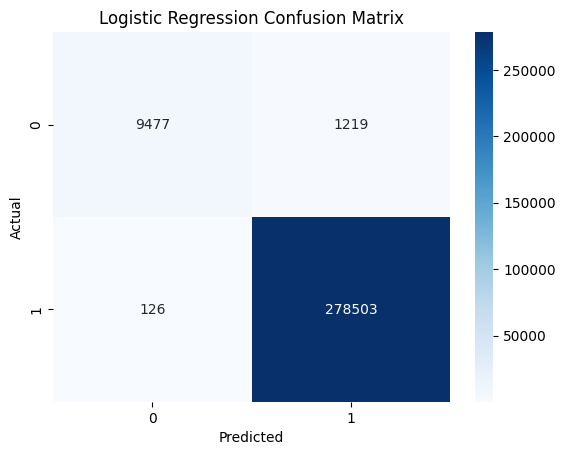


Random Forest Performance:
Accuracy: 0.9952, Precision: 0.9970, Recall: 0.9981, F1-score: 0.9975


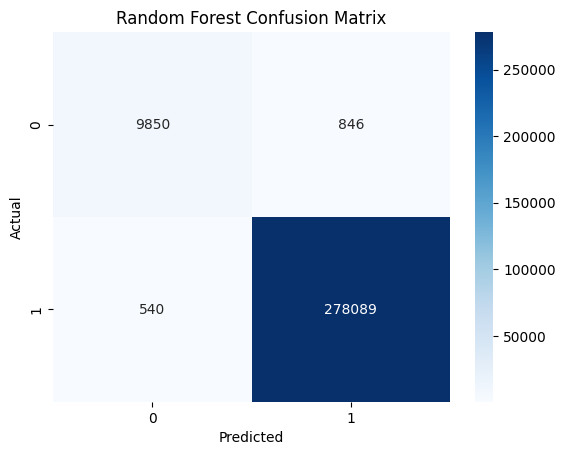

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Linear SVM Performance:
Accuracy: 0.9954, Precision: 0.9957, Recall: 0.9996, F1-score: 0.9976


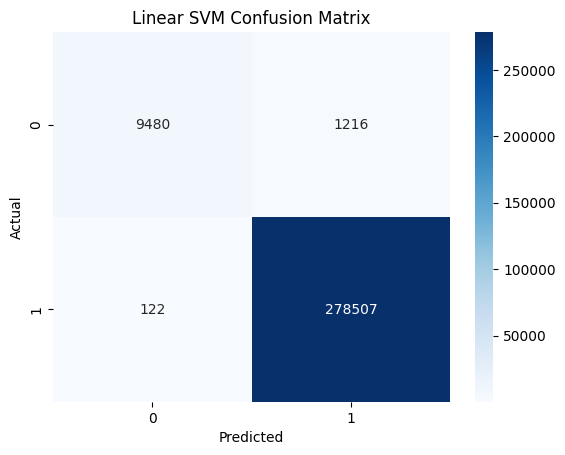

In [ ]:
# 🔹 Helper function for evaluation
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d",cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 🔹 Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
evaluate_model(lr, X_test, y_test, "Logistic Regression")

# 🔹 Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test, "Random Forest")

# 🔹 Linear SVM (faster alternative)
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train, y_train)
evaluate_model(svm, X_test, y_test, "Linear SVM")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9886 - loss: 0.0510 - val_accuracy: 0.9951 - val_loss: 0.0152
Epoch 2/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9953 - loss: 0.0162 - val_accuracy: 0.9959 - val_loss: 0.0140
Epoch 3/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9955 - loss: 0.0147 - val_accuracy: 0.9958 - val_loss: 0.0149
Epoch 4/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9957 - loss: 0.0148 - val_accuracy: 0.9962 - val_loss: 0.0128
Epoch 5/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9958 - loss: 0.0137 - val_accuracy: 0.9961 - val_loss: 0.0126
Epoch 6/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9958 - loss: 0.0137 - val_accuracy: 0.9963 - val_loss: 0.0124
Epoch 7/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9961 - loss: 0.0133 - val_accuracy: 0.9965 - val_loss: 0.0120
Epoch 8/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9962 - loss: 0

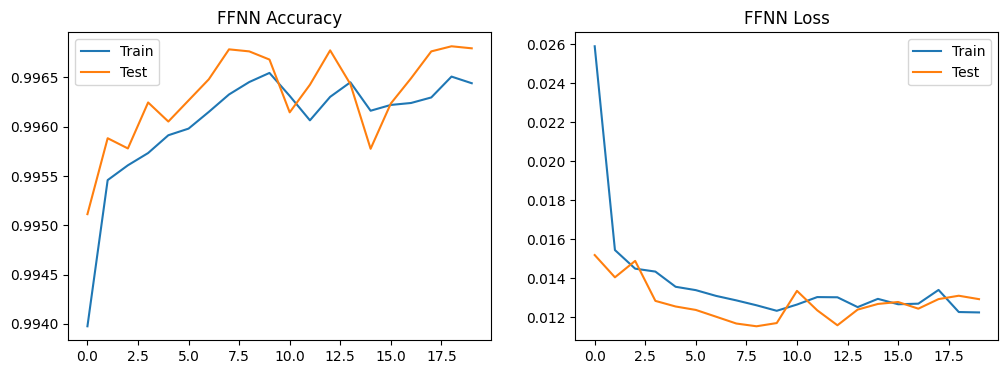

9042/9042 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


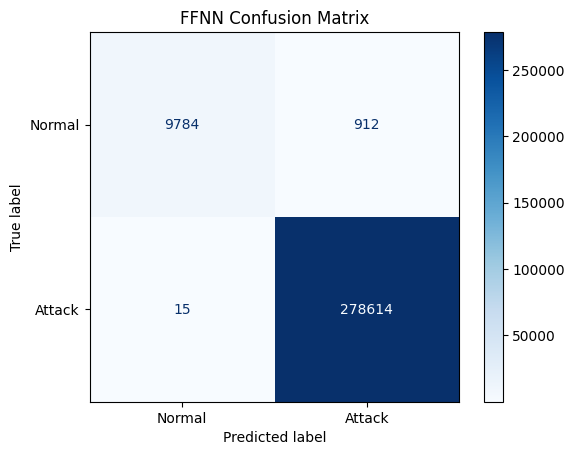

In [ ]:
# ✅ Assuming you already have df loaded and preprocessed with 'attack' as target
X = df.drop(columns=['attack'])
y = df['attack']

# ✅ Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ Convert labels to categorical (for softmax)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# ✅ Build FFNN Model
ffnn = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')  # 2 classes: normal (0) and attack (1)
])

# ✅ Compile the model
ffnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ Train the model
history = ffnn.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=256,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

# ✅ Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('FFNN Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('FFNN Loss')
plt.legend()

plt.show()

# Get predicted class labels
y_pred = ffnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap='Blues')
plt.title('FFNN Confusion Matrix')
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9920 - loss: 0.0427 - val_accuracy: 0.9957 - val_loss: 0.0167
Epoch 2/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9955 - loss: 0.0162 - val_accuracy: 0.9959 - val_loss: 0.0150
Epoch 3/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9956 - loss: 0.0150 - val_accuracy: 0.9960 - val_loss: 0.0132
Epoch 4/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9962 - loss: 0.0132 - val_accuracy: 0.9962 - val_loss: 0.0125
Epoch 5/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9966 - loss: 0.0121 - val_accuracy: 0.9968 - val_loss: 0.0115
Epoch 6/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9967 - loss: 0.0121 - val_accuracy: 0.9969 - val_loss: 0.0113
Epoch 7/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9967 - loss: 0.0119 - val_accuracy: 0.9968 - val_loss: 0.0114
Epoch 8/20
4521/4521 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9967 - loss: 0

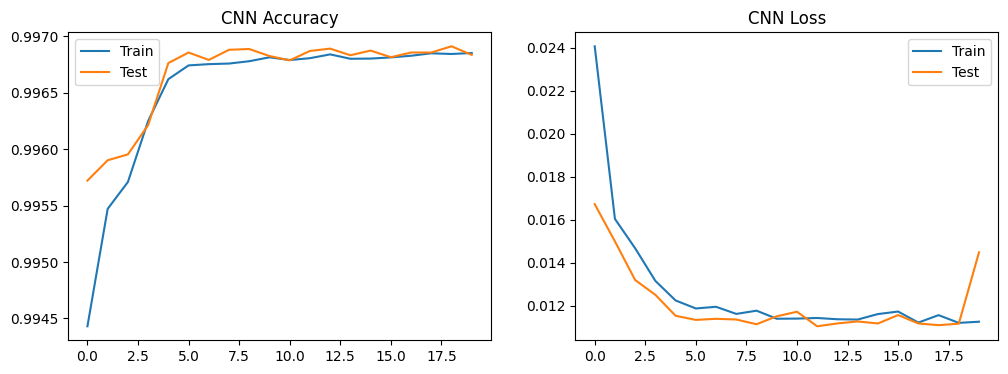

9042/9042 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


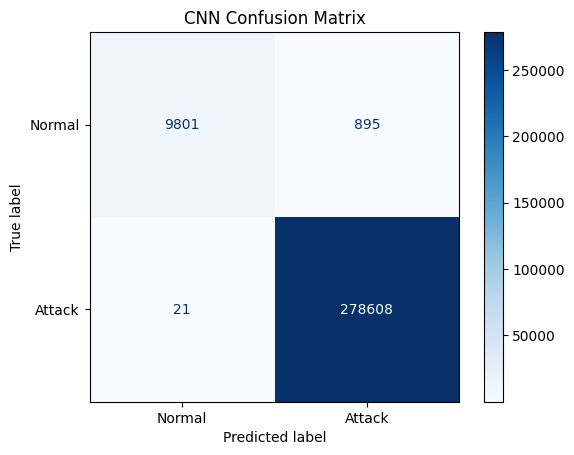

In [ ]:
# 🔹 Reshape data for Conv1D
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1],1)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=20, batch_size=256, validation_data=(X_test_cnn, y_test_cat), verbose=1)

# 🔹 Plot CNN history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Test')
plt.title('CNN Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Test')
plt.title('CNN Loss')
plt.legend()
plt.show()

# Predict class labels
y_pred_cnn = cnn.predict(X_test_cnn)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)

# Generate confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_classes_cnn)

# Display confusion matrix
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=['Normal', 'Attack'])
disp_cnn.plot(cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.show()


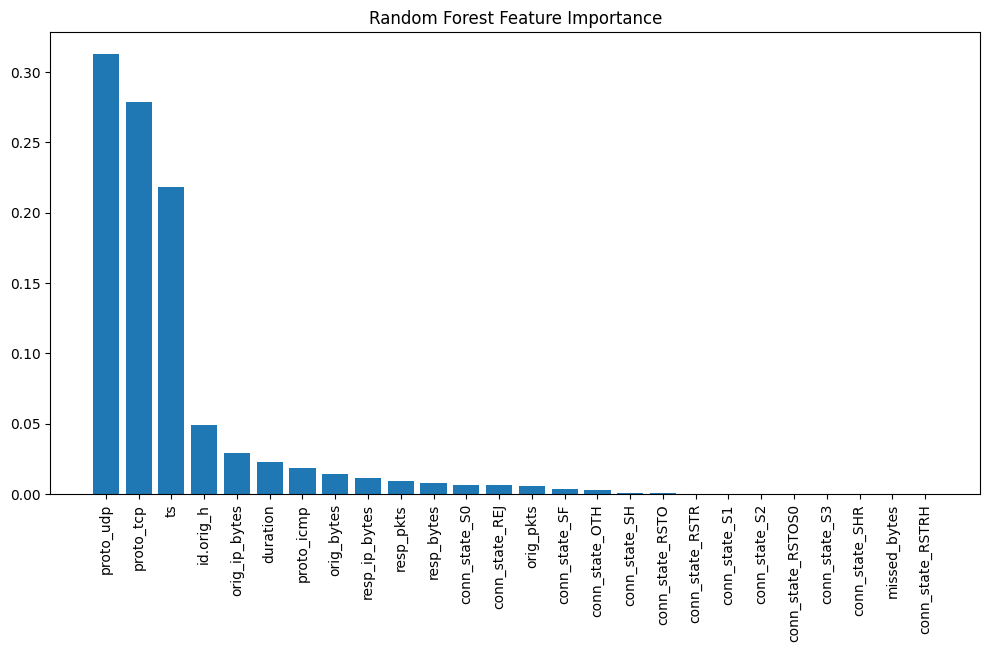

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Random Forest Feature Importance")
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), df.drop('attack', axis=1).columns[indices], rotation=90)
plt.show()


9042/9042 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
9042/9042 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step

📊 Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.995355,0.995642,0.999551,0.997593,0.993615
1,Random Forest,0.995776,0.996940,0.998679,0.997809,0.997645
2,Linear SVM,0.995375,0.995653,0.999562,0.997604,0.993757
3,FFNN,0.996796,0.996737,0.999946,0.998339,0.998341


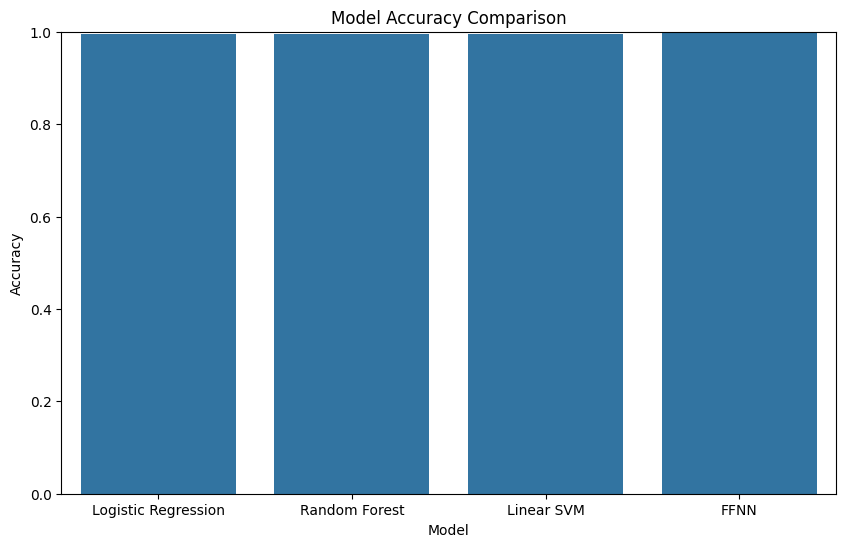

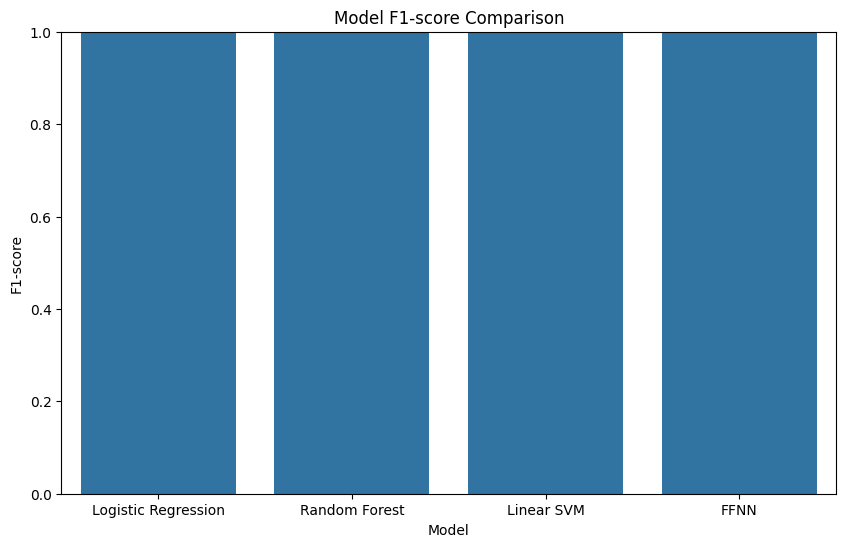

In [ ]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Linear SVM': svm
    }

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Handle AUC: LinearSVC has no predict_proba
    if hasattr(model, "predict_proba"):
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    else:
        auc = roc_auc_score(y_test, model.decision_function(X_test))

    results.append([name, acc, prec, rec, f1, auc])

# FFNN Predictions
y_pred_ffnn = np.argmax(ffnn.predict(X_test), axis=1)
acc_ffnn = accuracy_score(y_test, y_pred_ffnn)
prec_ffnn = precision_score(y_test, y_pred_ffnn)
rec_ffnn = recall_score(y_test, y_pred_ffnn)
f1_ffnn = f1_score(y_test, y_pred_ffnn)
auc_ffnn = roc_auc_score(y_test, ffnn.predict(X_test)[:, 1])
results.append(['FFNN', acc_ffnn, prec_ffnn, rec_ffnn, f1_ffnn, auc_ffnn])

# Results Table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'])

print("\n📊 Model Comparison Table:")
display(results_df)

# -----------------------------------------------------
# 📈 Plot Comparison Graphs
# -----------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='F1-score', data=results_df)
plt.title('Model F1-score Comparison')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.show()